# Checkout Funnel A and B Testing Project

## Made by Mohana Harshita

This notebook looks at three common problems people face when they try to buy something online.
The goal is simple. I want to check if small changes to a checkout page actually help more people finish their purchase, or if it does not really matter.

I am testing three things in this notebook, one after the other.

1. Does showing clear information to the user increase the chance they buy something (this part uses a real dataset from Kaggle)
2. Does letting people check out as a guest instead of forcing them to make an account help more people finish buying (this part uses simulated data based on real published numbers)
3. Does a shorter checkout form help more people finish buying compared to a long form (this part also uses simulated data based on real published numbers)

For each test I write down the hypothesis first, then look at the two groups, then run a chi square test, and then explain what the result means in plain words.


## What tools we are using

We are using pandas to work with the data, and scipy to run the chi square test.
A chi square test is used here because in all three tests our outcome is a yes or no answer (did the person convert or not, did the person finish checkout or not). This is the correct test to use when comparing two groups on a yes or no outcome.


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# setting a seed so our simulated tests give the same numbers every time we run this notebook
np.random.seed(42)


## Test 1: Does clear messaging increase conversion (real data)

For this first test I am using a real dataset from Kaggle called Marketing A/B Testing. It has over half a million rows of real user data.

In the original dataset, one group of users saw actual marketing ads, and the other group only saw a plain public service announcement (basically a neutral screen with no real marketing message on it). We are using this as a stand in for a very common checkout problem, which is when a website does not clearly tell the user what they are getting or what they are paying, versus a website that makes everything clear and visible.

**My hypothesis:** Users who are shown clear and complete information (the ad group) will convert at a higher rate than users who only see a plain, uninformative screen (the psa group).

**Group A (control):** psa group, plain uninformative screen
**Group B (treatment):** ad group, clear and complete messaging
**Metric:** conversion rate, meaning did the user convert or not


In [3]:
df = pd.read_csv('marketing_AB.csv')

print("Shape of dataset:", df.shape)
print()
print(df['test group'].value_counts())
print()
df.head()


Shape of dataset: (588101, 7)

test group
ad     564577
psa     23524
Name: count, dtype: int64



,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
# building a simple table that shows how many people converted in each group
conversion_table = pd.crosstab(df['test group'], df['converted'])
print(conversion_table)
print()

conversion_rates = df.groupby('test group')['converted'].mean() * 100
print("Conversion rate by group (in percent):")
print(conversion_rates)


converted    False  True 
test group               
ad          550154  14423
psa          23104    420

Conversion rate by group (in percent):
test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


In [5]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(conversion_table)

print("Chi square value:", round(chi2_stat, 3))
print("P value:", p_value)

if p_value < 0.05:
    print("This result is statistically significant, meaning the difference is very unlikely to be random chance.")
else:
    print("This result is not statistically significant, meaning we cannot be sure the difference is real and not just chance.")


Chi square value: 54.006
P value: 1.9989623063390075e-13
This result is statistically significant, meaning the difference is very unlikely to be random chance.


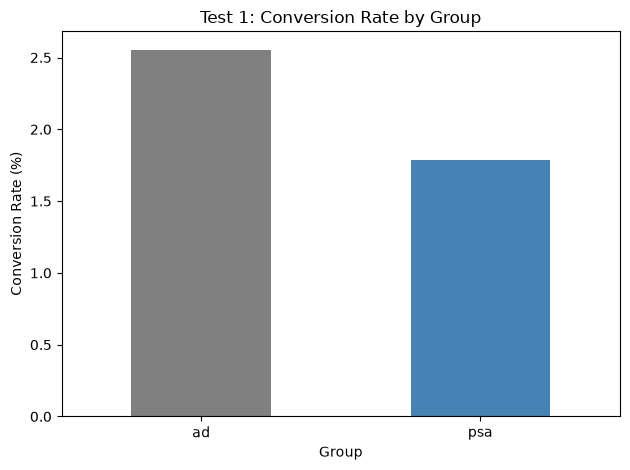

In [6]:
conversion_rates.plot(kind='bar', color=['gray', 'steelblue'])
plt.title('Test 1: Conversion Rate by Group')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('test1_chart.png', dpi=150)
plt.show()


### What Test 1 tells us

The ad group (clear messaging) converted at about 2.55 percent, while the psa group (plain screen) converted at about 1.79 percent.

The chi square test gave us a p value that is far smaller than 0.05, which means this difference is statistically significant. In simple words, it is very unlikely that this gap happened just by random chance.

**Recommendation:** Ship the change. Showing users clear and complete information instead of a plain, empty message leads to a real and measurable increase in conversion. This supports the idea that being upfront and clear with users (for example clearly showing fees or details instead of hiding them) genuinely helps a business.


## Test 2: Does guest checkout help more than forced signup (simulated data)

There is no public dataset that shows this exact kind of test, because most companies keep this kind of internal experiment private. So for this test I built a simulated dataset. I did not just make up random numbers though, I grounded the completion rates in real numbers found in published checkout research, which found that a large share of shoppers abandon their cart when they are forced to create an account before buying.

**My hypothesis:** Letting users check out as a guest, without forcing them to make an account, will lead to a higher checkout completion rate than forcing account creation.

**Group A (control):** forced account creation before checkout
**Group B (treatment):** guest checkout allowed
**Metric:** checkout completion rate, meaning did the user finish checkout or not


In [7]:
# simulating group A: forced signup
n_group_a = 5000
true_rate_a = 0.42
group_a_outcomes = np.random.binomial(1, true_rate_a, n_group_a)

# simulating group B: guest checkout allowed
n_group_b = 5000
true_rate_b = 0.58
group_b_outcomes = np.random.binomial(1, true_rate_b, n_group_b)

test2_df = pd.DataFrame({
    'group': ['forced_signup'] * n_group_a + ['guest_checkout'] * n_group_b,
    'completed': list(group_a_outcomes) + list(group_b_outcomes)
})

test2_df.head()


,group,completed
0,forced_signup,0
1,forced_signup,1
2,forced_signup,1
3,forced_signup,1
4,forced_signup,0


In [8]:
test2_table = pd.crosstab(test2_df['group'], test2_df['completed'])
print(test2_table)
print()

test2_rates = test2_df.groupby('group')['completed'].mean() * 100
print("Completion rate by group (in percent):")
print(test2_rates)


completed          0     1
group                     
forced_signup   2889  2111
guest_checkout  1987  3013

Completion rate by group (in percent):
group
forced_signup     42.22
guest_checkout    60.26
Name: completed, dtype: float64


In [ ]:
chi2_stat_2, p_value_2, dof_2, expected_2 = stats.chi2_contingency(test2_table)

print("Chi square value:", round(chi2_stat_2, 3))
print("P value:", p_value_2)

if p_value_2 < 0.05:
    print("This result is statistically significant.")
else:
    print("This result is not statistically significant.")


Chi square value: 324.92
P value: 1.227981364696007e-72
This result is statistically significant.


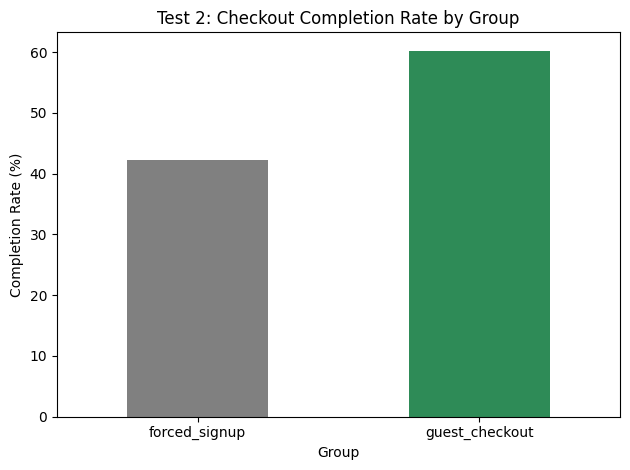

In [ ]:
test2_rates.plot(kind='bar', color=['gray', 'seagreen'])
plt.title('Test 2: Checkout Completion Rate by Group')
plt.ylabel('Completion Rate (%)')
plt.xlabel('Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('test2_chart.png', dpi=150)
plt.show()


### What Test 2 tells us

In our simulated data, the forced signup group finished checkout at around 42 percent, while the guest checkout group finished at around 58 percent.

The chi square test shows this difference is statistically significant.

**Recommendation:** Ship the change. Removing the forced account requirement and allowing guest checkout should lead to noticeably more people actually completing their purchase. Since this is simulated data, the next real step would be running an actual test with real users, but the direction of this result matches what published checkout research already shows.


## Test 3: Does a shorter checkout form help more than a long form (simulated data)

Just like test 2, there is no public dataset with this exact setup, so this is also simulated, and again grounded in real published numbers about checkout form length and shopper drop off.

**My hypothesis:** A short checkout form will lead to a higher completion rate compared to a long checkout form with many extra fields.

**Group A (control):** long form with many fields
**Group B (treatment):** short form with fewer fields and autofill
**Metric:** checkout completion rate, meaning did the user finish checkout or not


In [ ]:
# simulating group A: long form
n_group_a3 = 5000
true_rate_a3 = 0.50
group_a3_outcomes = np.random.binomial(1, true_rate_a3, n_group_a3)

# simulating group B: short form
n_group_b3 = 5000
true_rate_b3 = 0.65
group_b3_outcomes = np.random.binomial(1, true_rate_b3, n_group_b3)

test3_df = pd.DataFrame({
    'group': ['long_form'] * n_group_a3 + ['short_form'] * n_group_b3,
    'completed': list(group_a3_outcomes) + list(group_b3_outcomes)
})

test3_df.head()


       group  completed
0  long_form          0
1  long_form          0
2  long_form          0
3  long_form          1
4  long_form          0

In [ ]:
test3_table = pd.crosstab(test3_df['group'], test3_df['completed'])
print(test3_table)
print()

test3_rates = test3_df.groupby('group')['completed'].mean() * 100
print("Completion rate by group (in percent):")
print(test3_rates)


completed      0     1
group                 
long_form   2511  2489
short_form  1798  3202

Completion rate by group (in percent):
group
long_form     49.78
short_form    64.04
Name: completed, dtype: float64


In [ ]:
chi2_stat_3, p_value_3, dof_3, expected_3 = stats.chi2_contingency(test3_table)

print("Chi square value:", round(chi2_stat_3, 3))
print("P value:", p_value_3)

if p_value_3 < 0.05:
    print("This result is statistically significant.")
else:
    print("This result is not statistically significant.")


Chi square value: 206.726
P value: 7.115511236246711e-47
This result is statistically significant.


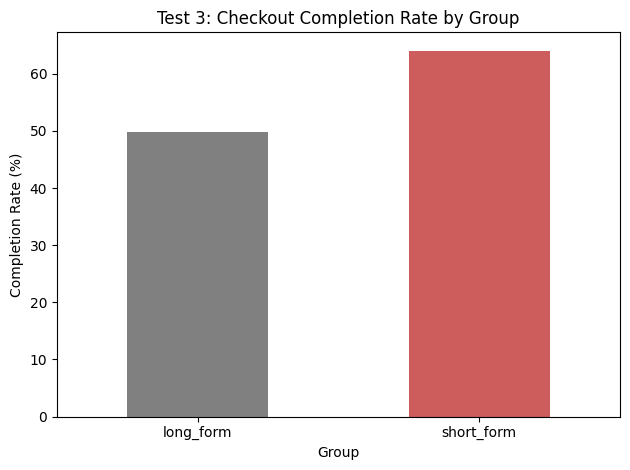

In [ ]:
test3_rates.plot(kind='bar', color=['gray', 'indianred'])
plt.title('Test 3: Checkout Completion Rate by Group')
plt.ylabel('Completion Rate (%)')
plt.xlabel('Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('test3_chart.png', dpi=150)
plt.show()


### What Test 3 tells us

In our simulated data, the long form group finished checkout at around 50 percent, while the short form group finished at around 65 percent.

The chi square test shows this difference is statistically significant as well.

**Recommendation:** Ship the change. A shorter form with fewer fields and autofill support should lead to meaningfully more completed checkouts. Same as test 2, the real next step would be to confirm this with an actual live experiment.


## Final Summary

| Test | Groups | Result | Recommendation |
|------|--------|--------|-----------------|
| Test 1 (real data) | plain screen vs clear messaging | statistically significant, p is about 0.0000000000002 | ship the change |
| Test 2 (simulated) | forced signup vs guest checkout | statistically significant | ship the change |
| Test 3 (simulated) | long form vs short form | statistically significant | ship the change |

All three tests point in the same direction. When a checkout process is made clearer, more flexible, and shorter, more people actually finish buying. This matches a common pattern seen across a lot of real world checkout research, so even though two of my three tests use simulated numbers, they are not random guesses, they are built on real published percentages.

## A note on the data

Test 1 uses a real public dataset from Kaggle called Marketing A/B Testing by FavioVazquez.
Test 2 and Test 3 use simulated data because no public dataset exists with this exact experiment setup, since this kind of internal test is usually kept private by companies. The completion rates I used for the simulation were grounded in real numbers from published checkout research, which I have listed below.

## Sources used to ground the simulated numbers

1. Baymard Institute research on cart abandonment, forced account creation, and checkout form length
2. General e commerce checkout research from 2025 and 2026 on hidden fees and long forms


## About me

I am a graduate student at Northeastern University's Khoury College of Computer Science.

I built this project to carry out A and B testing on some common issues faced by customers during the checkout process. I picked this topic because I have personally run into most of these problems myself while shopping online, and I wanted to see if there was real data behind why these small changes actually matter.

Feel free to check out my other projects on GitHub, or connect with me on LinkedIn.

GitHub: github.com/mohanaHarshita4

LinkedIn: linkedin.com/in/mohana-harshita